In [1]:
import itertools
import numpy as np
import scipy as sp
from matplotlib import pyplot as plt
import pandas as pd
import seaborn as sns
import pickle


import STX3KO_analyses as stx
from STX3KO_analyses import utilities as u

ko_mice = stx.ymaze_sess_deets.ko_mice
ctrl_mice = stx.ymaze_sess_deets.ctrl_mice
sparse_mice = stx.ymaze_sess_deets.sparse_mice

plt.rcParams['pdf.fonttype']=42
plt.rcParams['font.family'] ='sans-serif'
plt.rcParams['font.serif'] = 'Arial'


%matplotlib inline

%load_ext autoreload
%autoreload 2

In [2]:
import pickle 
with open('/home/mplitt/shuffle_pkls/dense_place_field_spatial_shuffle_F_dff.pkl','rb') as file:
    shuff_results = pickle.load(file)

In [ ]:
mice = ctrl_mice
days =np.arange(6)
max_trial = 5

: 

In [ ]:
fig, ax = plt.subplots()
x = np.arange(max_trial)


for cond, mice in zip(('ko','ctrl'), (ko_mice, ctrl_mice)):
    argmax_mat = []
    for mouse in mice:
        for day in range(1): 
            sess = u.load_single_day(mouse, day)
            for ttype in ('nov',):
                
                fields_dict = shuff_results[mouse][day][ttype]


                if ttype =='fam':
                    trial_mask = sess.trial_info['LR']!=sess.novel_arm
                else:
                    trial_mask = sess.trial_info['LR']==sess.novel_arm

                trial_mat = sess.trial_matrices['F_dff'][trial_mask,:,:]

                shifts, inds = stx.single_field_shifts.get_field_shifts(trial_mat, fields_dict, ttype)
                argmax_mat.append(stx.single_field_shifts.shifts_to_matrix(shifts, max_trial))
                # print(argmax_mat)

                # if cond == 'ko':
                #     ax.plot(x, argmax_mat.mean(axis=0), color='red')
                # else:
                #     ax.plot(x, argmax_mat.mean(axis=0), color='black')

    argmax_mat = np.concatenate(argmax_mat,axis=0)
    mu, sem = argmax_mat.mean(axis=0), sp.stats.sem(argmax_mat,axis=0)
    if cond == 'ko':
        color = 'red'
        
    else:
        color='black'
    
    ax.plot(x, mu, color=color)
    ax.fill_between(x, mu-sem, mu+sem, color=color,alpha=.4)


{'date': '28_09_2020', 'scene': 'YMaze_LNovel', 'session': 6, 'scan': 14, 'novel_arm': -1, 'ravel_ind': 1}


/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:232: UserWarning: Could not find sbxmat file at /mnt/BigDisk/2P_scratch/4467975.1/28_09_2020/YMaze_LNovel/YMaze_LNovel_006_014.mat
  warnings.warn("Could not find sbxmat file at %s" % self.scanheader_file)
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:241: UserWarning: Could not find sbx file at /mnt/BigDisk/2P_scratch/4467975.1/28_09_2020/YMaze_LNovel/YMaze_LNovel_006_014.sbx
  warnings.warn("Could not find sbx file at %s" % self.scan_file)


{'date': '28_09_2020', 'scene': 'YMaze_LNovel', 'session': 3, 'scan': 8, 'novel_arm': 1, 'ravel_ind': 0}


/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:232: UserWarning: Could not find sbxmat file at /mnt/BigDisk/2P_scratch/4467975.2/28_09_2020/YMaze_LNovel/YMaze_LNovel_003_008.mat
  warnings.warn("Could not find sbxmat file at %s" % self.scanheader_file)
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:241: UserWarning: Could not find sbx file at /mnt/BigDisk/2P_scratch/4467975.2/28_09_2020/YMaze_LNovel/YMaze_LNovel_003_008.sbx
  warnings.warn("Could not find sbx file at %s" % self.scan_file)


{'date': '28_09_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 4, 'novel_arm': -1, 'ravel_ind': 0}


/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:232: UserWarning: Could not find sbxmat file at /mnt/BigDisk/2P_scratch/4467975.3/28_09_2020/YMaze_LNovel/YMaze_LNovel_001_004.mat
  warnings.warn("Could not find sbxmat file at %s" % self.scanheader_file)
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:241: UserWarning: Could not find sbx file at /mnt/BigDisk/2P_scratch/4467975.3/28_09_2020/YMaze_LNovel/YMaze_LNovel_001_004.sbx
  warnings.warn("Could not find sbx file at %s" % self.scan_file)


{'date': '28_09_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 5, 'novel_arm': 1, 'ravel_ind': 0}


In [7]:
min_trial_num=5

[0.71428571 0.67532468 0.76363636 0.35324675 0.26493506] [0.1083803  0.11456485 0.10594768 0.1072317  0.10732685]


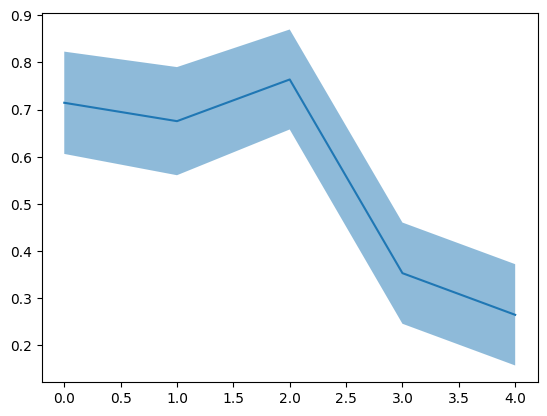

In [10]:
fig,ax = plt.subplots()
mu, sem = argmax_mat.mean(axis=0), sp.stats.sem(argmax_mat,axis=0, nan_policy='omit')
print(mu,sem)
x = np.arange(5)
ax.plot(x, mu)
ax.fill_between(x, mu-sem, mu+sem, alpha=.5)


In [12]:
for k, v in fields_dict.items():
    print(k, v.shape)

field_mask (30, 1381)
rising_edges (1225, 2)
falling_edges (1225, 2)
field_widths (1225,)
num_fields (1379,)
